**Entering** **Data**

In [2]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("DSA210-project-data.csv")
df

,Year,Country,ISO3,GDP_Per_Capita,Population_Growth_Rate,Source
0,2000,Afghanistan,AFG,174.930991,NaN,World Bank API
1,2001,Afghanistan,AFG,116860.028200,1.666359,World Bank API
2,2002,Afghanistan,AFG,565.569730,NaN,World Bank API
3,2003,Afghanistan,AFG,40354.281030,-1.059785,World Bank API
4,2004,Afghanistan,AFG,2446.909499,-0.417931,World Bank API
...,...,...,...,...,...,...
5065,2021,Zimbabwe,ZWE,824.028192,1.402030,World Bank API
5066,2022,Zimbabwe,ZWE,2877.393314,-0.522606,World Bank API
5067,2023,Zimbabwe,ZWE,2578.666894,2.009991,World Bank API
5068,2024,Zimbabwe,ZWE,4009.320221,1.003451,World Bank API


**Cleaning Data**

In [3]:
# first of all, as we do not need the resource of the data, we can delete the column.
df = df[["Year", "Country", "GDP_Per_Capita", "Population_Growth_Rate"]]

length_before = len(df)
# deleting the missing values because of the errors they may make
df = df.dropna(subset=["GDP_Per_Capita", "Population_Growth_Rate"])
length_after = len(df)
# how may rows are deleted?
deleted_rows = length_before -  length_after
print(f"{deleted_rows} rows contined missing data which are eliminated")


26 rows contined missing data which are eliminated


**Enrichment**

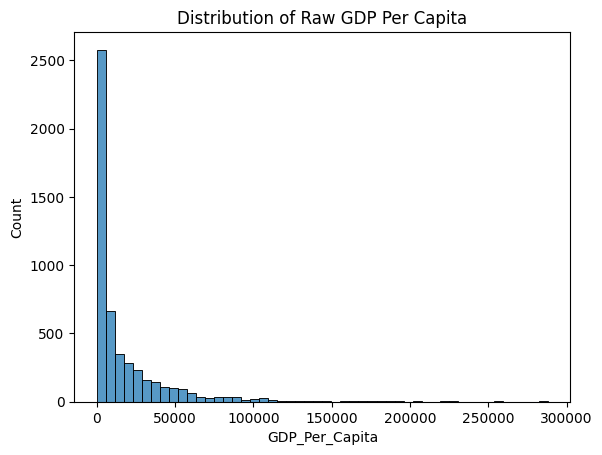

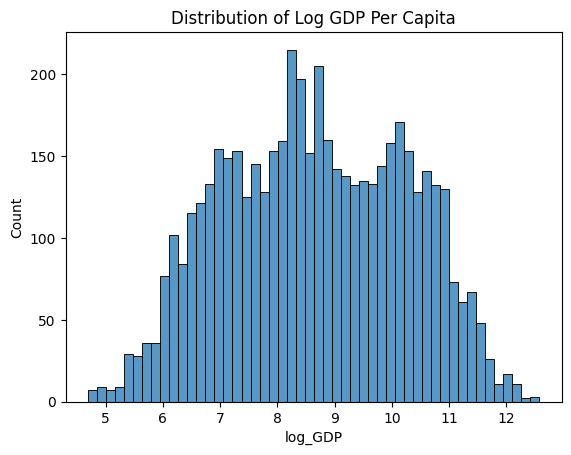

In [4]:
plt.figure()
sns.histplot(df["GDP_Per_Capita"], bins=50)
plt.title("Distribution of Raw GDP Per Capita")
plt.show()


df["log_GDP"] = np.log(df["GDP_Per_Capita"])
plt.figure()
sns.histplot(df["log_GDP"], bins=50)
plt.title("Distribution of Log GDP Per Capita")
plt.show()

As we can see here, the normal GDP_Per_Capita we have in our data:

1. distribution is highly right skewed
2. this histogram indicates the exponential distribution in this data

Both of the things above makes the work so harder for us in terms of interpreting the data + dificully in regression and forcasting

To be dealingw with these two problems, we use the log GDP method.
This method firstly made the distribution linear which is way easier while forecasting, etc., in addition to making the counts distribution standard normal which is most preferred in data analysis.


<Axes: title={'center': 'Raw GDP Per Capita Over Time'}, xlabel='Year'>

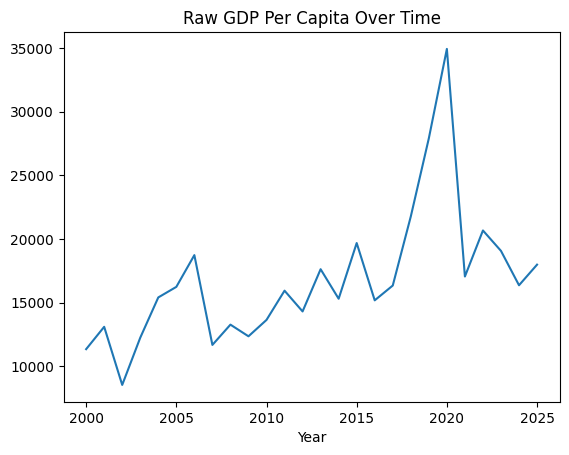

In [5]:
df.groupby("Year")["GDP_Per_Capita"].mean().plot(title="Raw GDP Per Capita Over Time")

<Axes: title={'center': 'Log GDP Per Capita Over Time'}, xlabel='Year'>

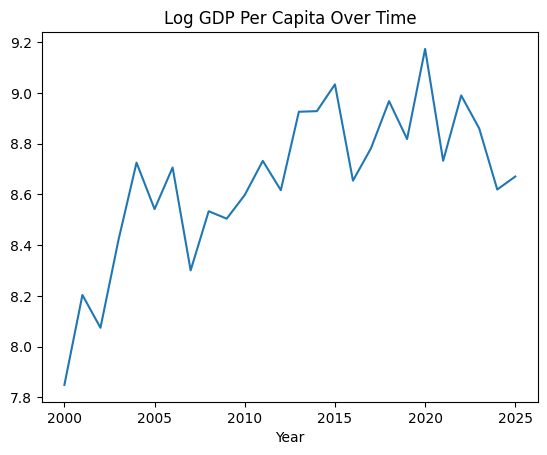

In [6]:
df.groupby("Year")["log_GDP"].mean().plot(title="Log GDP Per Capita Over Time")

In last two steps, we saw how data became more linear oriented rather than exponentialy.

Adding Log GDP and Categorizing in term of that, add the column representing if thr GDP of the country in the specific year was considered as High or Low to generally come up with that if the country is rich or poor generally.


In [7]:
# here we wanna categorize if the country had a low or high gdp in certain year and also add continents to be able to compare continentwise
# Calculate median GDP per year for the world
df["GDP_Year"] = df.groupby("Year")["GDP_Per_Capita"].transform("median")

# decide if the countrie's gdp was high or low with respect to the whole world year's gdp
df["GDP_Year"] = df.apply(lambda row: "High GDP" if row["GDP_Per_Capita"] > row["GDP_Year"] else "Low GDP", axis=1)

df


,Year,Country,GDP_Per_Capita,Population_Growth_Rate,log_GDP,GDP_Year
1,2001,Afghanistan,116860.028200,1.666359,11.668732,High GDP
3,2003,Afghanistan,40354.281030,-1.059785,10.605453,High GDP
4,2004,Afghanistan,2446.909499,-0.417931,7.802581,Low GDP
5,2005,Afghanistan,72004.743700,1.200776,11.184487,High GDP
6,2006,Afghanistan,6069.439031,-1.543137,8.711021,High GDP
...,...,...,...,...,...,...
5065,2021,Zimbabwe,824.028192,1.402030,6.714205,Low GDP
5066,2022,Zimbabwe,2877.393314,-0.522606,7.964640,Low GDP
5067,2023,Zimbabwe,2578.666894,2.009991,7.855028,Low GDP
5068,2024,Zimbabwe,4009.320221,1.003451,8.296377,Low GDP


Here, we wanna add the continent of the country. Later on, we can compare growth rates and GDP rates and their reations contienentwise as well.


In [8]:
continent_map = {
    "Africa": [
        "algeria","angola","benin","botswana","burkina faso","burundi","cameroon","cape verde",
        "central african republic","chad","comoros","congo","democratic republic of the congo",
        "djibouti","egypt","equatorial guinea","eritrea","eswatini","ethiopia","gabon","gambia",
        "ghana","guinea","guinea-bissau","ivory coast","kenya","lesotho","liberia","libya",
        "madagascar","malawi","mali","mauritania","mauritius","morocco","mozambique","namibia",
        "niger","nigeria","rwanda","sao tome and principe","senegal","seychelles","sierra leone",
        "somalia","south africa","south sudan","sudan","tanzania","togo","tunisia","uganda",
        "zambia","zimbabwe"
    ],

    "Asia": [
        "afghanistan","armenia","azerbaijan","bahrain","bangladesh","bhutan","brunei",
        "cambodia","china","cyprus","georgia","india","indonesia","iran","iraq","israel",
        "japan","jordan","kazakhstan","kuwait","kyrgyzstan","laos","lebanon","malaysia",
        "maldives","mongolia","myanmar","nepal","north korea","oman","pakistan",
        "palestine","philippines","qatar","saudi arabia","singapore","south korea",
        "sri lanka","syria","taiwan","tajikistan","thailand","timor-leste","turkey",
        "turkmenistan","united arab emirates","uzbekistan","vietnam","yemen"
    ],

    "Europe": [
        "albania","andorra","austria","belarus","belgium","bosnia and herzegovina","bulgaria",
        "croatia","czech republic","denmark","estonia","finland","france","germany","greece",
        "hungary","iceland","ireland","italy","kosovo","latvia","liechtenstein","lithuania",
        "luxembourg","malta","moldova","monaco","montenegro","netherlands","north macedonia",
        "norway","poland","portugal","romania","russia","san marino","serbia","slovakia",
        "slovenia","spain","sweden","switzerland","ukraine","united kingdom","vatican city"
    ],

    "North America": [
        "antigua and barbuda","bahamas","barbados","belize","canada","costa rica","cuba",
        "dominica","dominican republic","el salvador","grenada","guatemala","haiti",
        "honduras","jamaica","mexico","nicaragua","panama","saint kitts and nevis",
        "saint lucia","saint vincent and the grenadines","trinidad and tobago","united states"
    ],

    "South America": [
        "argentina","bolivia","brazil","chile","colombia","ecuador","guyana","paraguay",
        "peru","suriname","uruguay","venezuela"
    ],

    "Oceania": [
        "australia","fiji","kiribati","marshall islands","micronesia","nauru","new zealand",
        "palau","papua new guinea","samoa","solomon islands","tonga","tuvalu","vanuatu"
    ]
}

df["Country"] = df["Country"].str.lower()
country_to_continent = {}

for continent, countries in continent_map.items():
    for country in countries:
        country_to_continent[country] = continent
df["Continent"] = df["Country"].map(country_to_continent)



# check if there is any country or generally smth. missing in our continent_map

df[df["Continent"].isnull()]["Country"].unique()


array(['american samoa', 'aruba', 'bahamas, the', 'bermuda',
       'british virgin islands', 'brunei darussalam', 'cabo verde',
       'cayman islands', 'channel islands', 'congo, dem. rep.',
       'congo, rep.', "cote d'ivoire", 'curacao', 'czechia',
       'egypt, arab rep.', 'french polynesia', 'guam',
       'hong kong sar, china', 'iran, islamic rep.', 'isle of man',
       "korea, dem. people's rep.", 'kyrgyz republic', 'macao sar, china',
       'new caledonia', 'northern mariana islands', 'puerto rico (us)',
       'russian federation', 'sint maarten (dutch part)',
       'slovak republic', 'somalia, fed. rep.', 'st. lucia',
       'st. martin (french part)', 'st. vincent and the grenadines',
       'syrian arab republic', 'turkiye', 'turks and caicos islands',
       'venezuela, rb', 'viet nam', 'virgin islands (u.s.)',
       'west bank and gaza', 'yemen, rep.'], dtype=object)

In [9]:
fix_continent = {
    # North America (Caribbean + territories)
    "aruba": "North America",
    "bahamas, the": "North America",
    "bermuda": "North America",
    "british virgin islands": "North America",
    "cayman islands": "North America",
    "curacao": "North America",
    "puerto rico (us)": "North America",
    "sint maarten (dutch part)": "North America",
    "st. lucia": "North America",
    "st. martin (french part)": "North America",
    "st. vincent and the grenadines": "North America",
    "turks and caicos islands": "North America",
    "virgin islands (u.s.)": "North America",

    # Africa
    "cabo verde": "Africa",
    "congo, dem. rep.": "Africa",
    "congo, rep.": "Africa",
    "cote d'ivoire": "Africa",
    "egypt, arab rep.": "Africa",
    "somalia, fed. rep.": "Africa",

    # Asia
    "brunei darussalam": "Asia",
    "hong kong sar, china": "Asia",
    "iran, islamic rep.": "Asia",
    "korea, dem. people's rep.": "Asia",
    "kyrgyz republic": "Asia",
    "macao sar, china": "Asia",
    "syrian arab republic": "Asia",
    "viet nam": "Asia",
    "yemen, rep.": "Asia",

    # Europe
    "channel islands":"Europe",
    "isle of man":"Europe",
    "slovak republic":"Europe",
    "czechia": "Europe",
    "russian federation":"Europe",

    # Oceania
    "american samoa": "Oceania",
    "french polynesia": "Oceania",
    "guam": "Oceania",
    "new caledonia": "Oceania",
    "northern mariana islands": "Oceania",

    # South America
    "venezuela, rb": "South America",


    "west bank and gaza": "Asia",
    "turkiye":"Euroupe"
}
df["Continent"] = df["Continent"].fillna(df["Country"].map(fix_continent))




# final check to get sure there is not country mising
df[df["Continent"].isnull()]["Country"].unique()
# output is empthy meaning that everything aboit assigning the contienents are fiixed


array([], dtype=object)

In [10]:
df

,Year,Country,GDP_Per_Capita,Population_Growth_Rate,log_GDP,GDP_Year,Continent
1,2001,afghanistan,116860.028200,1.666359,11.668732,High GDP,Asia
3,2003,afghanistan,40354.281030,-1.059785,10.605453,High GDP,Asia
4,2004,afghanistan,2446.909499,-0.417931,7.802581,Low GDP,Asia
5,2005,afghanistan,72004.743700,1.200776,11.184487,High GDP,Asia
6,2006,afghanistan,6069.439031,-1.543137,8.711021,High GDP,Asia
...,...,...,...,...,...,...,...
5065,2021,zimbabwe,824.028192,1.402030,6.714205,Low GDP,Africa
5066,2022,zimbabwe,2877.393314,-0.522606,7.964640,Low GDP,Africa
5067,2023,zimbabwe,2578.666894,2.009991,7.855028,Low GDP,Africa
5068,2024,zimbabwe,4009.320221,1.003451,8.296377,Low GDP,Africa


**EDA**

In [11]:
df.describe()

,Year,GDP_Per_Capita,Population_Growth_Rate,log_GDP
count,5044.000000,5044.000000,5044.000000,5044.000000
mean,2012.558089,16833.082100,1.263559,8.655219
std,7.475812,26887.201474,1.590013,1.580067
min,2000.000000,109.593814,-11.356645,4.696781
25%,2006.000000,1623.910426,0.329386,7.392592
50%,2013.000000,5601.960819,1.178398,8.630872
75%,2019.000000,20930.582120,2.135724,9.948967
max,2025.000000,288001.433400,21.700343,12.570721


As we can see, there are some outliers here. But for now I decided to keep them, because I want to compaire for example countinent with each other in this concept and small countries with high GDP, like Monaco, are gonna affect the result. So, naybe later I eliminate the outlier for regression purposes, etc. But now we will use median instead of mean in order not to be sensitive to outliers.

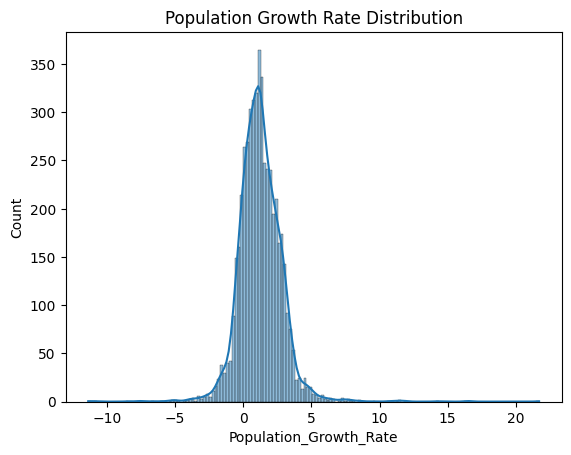

In [12]:
sns.histplot(df["Population_Growth_Rate"], kde=True)
plt.title("Population Growth Rate Distribution")
plt.show()

We do see that population growth rate also follows a standard normal distribution with the mean around 1.5.

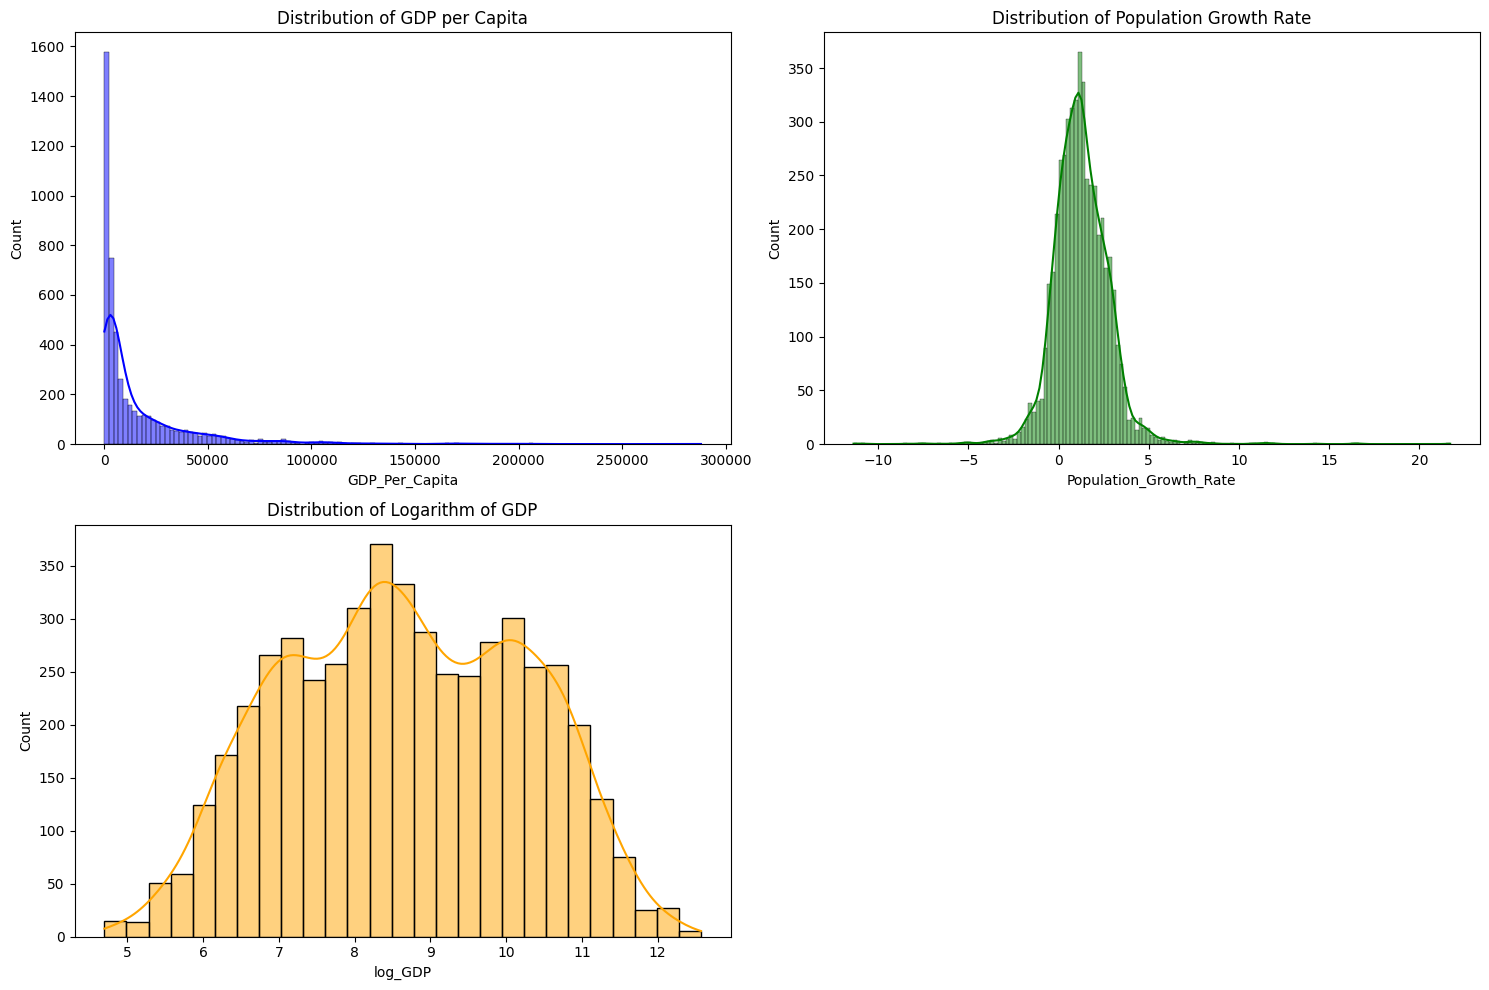

In [13]:

# Set up the figure
plt.figure(figsize=(15, 10))

# Plot histograms for important numerical features
plt.subplot(2, 2, 1)
sns.histplot(df['GDP_Per_Capita'], kde=True, color='blue')
plt.title('Distribution of GDP per Capita')

plt.subplot(2, 2, 2)
sns.histplot(df['Population_Growth_Rate'], kde=True, color='green')
plt.title('Distribution of Population Growth Rate')

plt.subplot(2, 2, 3)
sns.histplot(df['log_GDP'], kde=True, color='orange')
plt.title('Distribution of Logarithm of GDP')

# Display the plots
plt.tight_layout()
plt.show()

Visualizations on GDP_Per_Capita and Population_Growth_Rate in different continents.


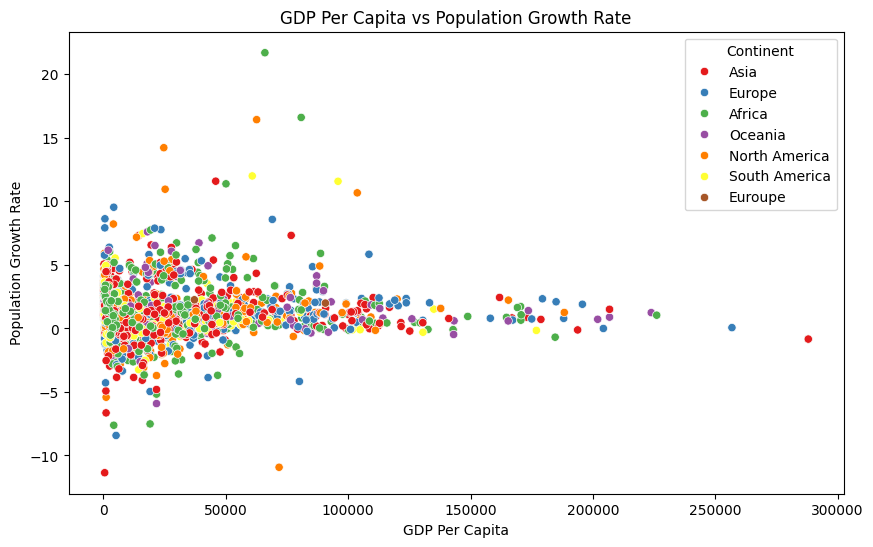

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GDP_Per_Capita', y='Population_Growth_Rate', hue='Continent', palette='Set1')
plt.title('GDP Per Capita vs Population Growth Rate')
plt.xlabel('GDP Per Capita')
plt.ylabel('Population Growth Rate')
plt.show()

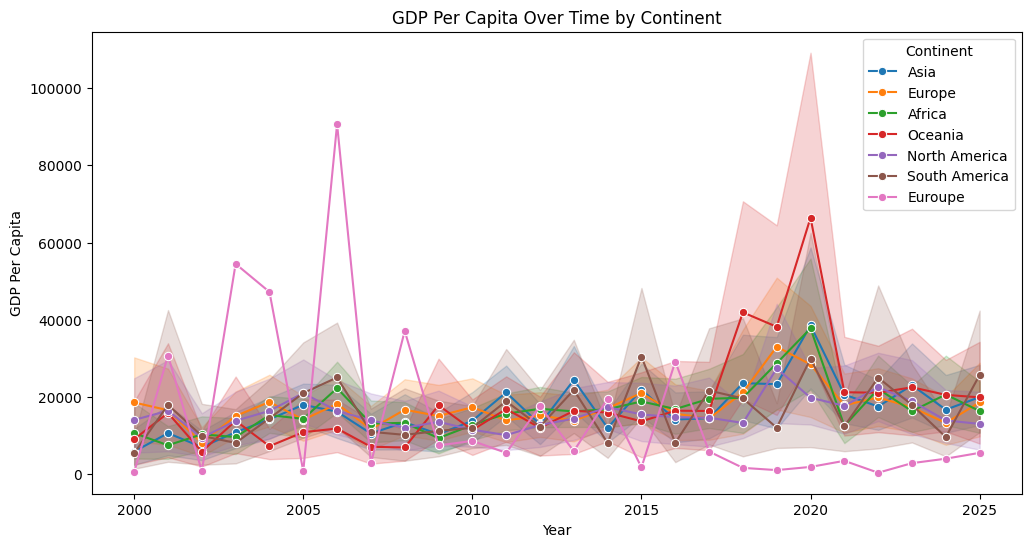

In [15]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='GDP_Per_Capita', hue='Continent', marker='o')
plt.title('GDP Per Capita Over Time by Continent')
plt.xlabel('Year')
plt.ylabel('GDP Per Capita')
plt.show()

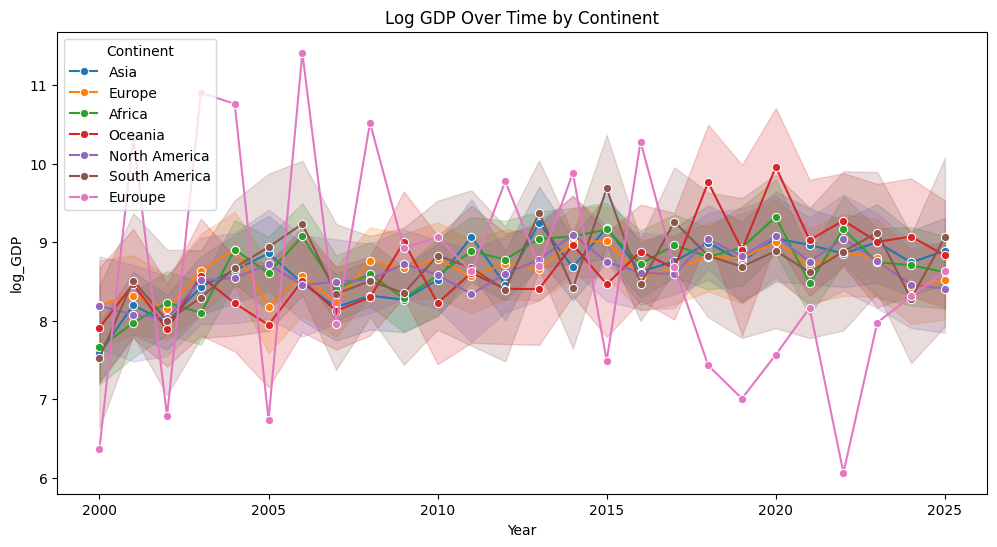

In [16]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='log_GDP', hue='Continent', marker='o')
plt.title('Log GDP Over Time by Continent')
plt.xlabel('Year')
plt.ylabel('log_GDP')
plt.show()

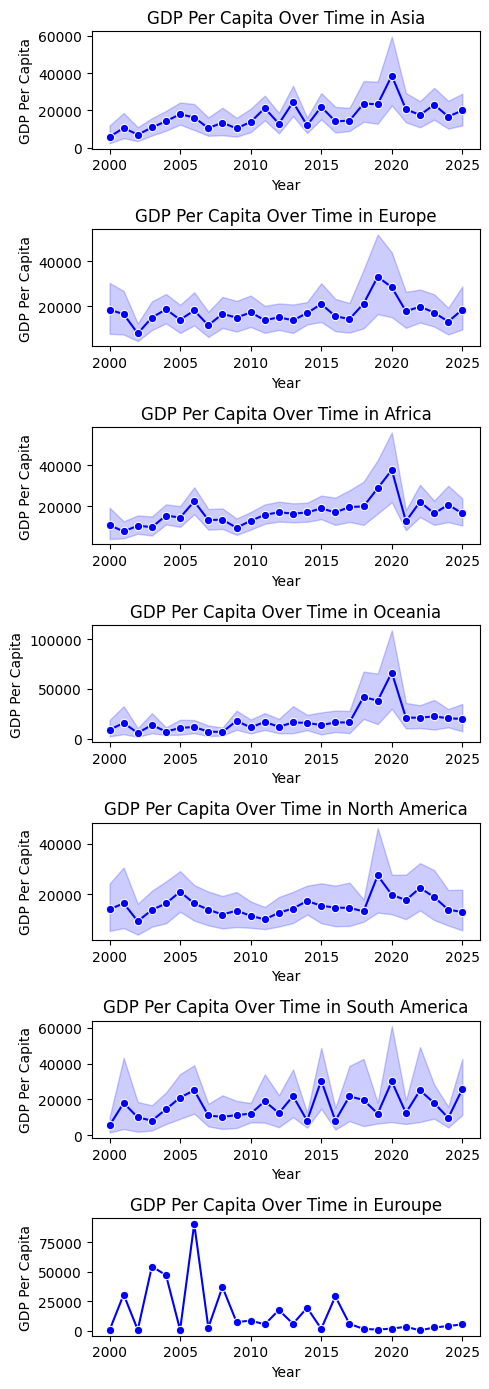

In [17]:
# Set up a grid of subplots (one for each continent)
continents = df['Continent'].unique()
num_continents = len(continents)

# Create subplots
fig, axes = plt.subplots(num_continents, 1, figsize=(5, 2 * num_continents))

# Loop through each continent and plot its GDP per Capita in a separate subplot
for i, continent in enumerate(continents):
    # Filter data for the continent
    continent_data = df[df['Continent'] == continent]

    # Plot GDP per Capita for this continent
    sns.lineplot(data=continent_data, x='Year', y='GDP_Per_Capita', ax=axes[i], color='blue', marker='o')

    # Add titles and labels
    axes[i].set_title(f'GDP Per Capita Over Time in {continent}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('GDP Per Capita')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

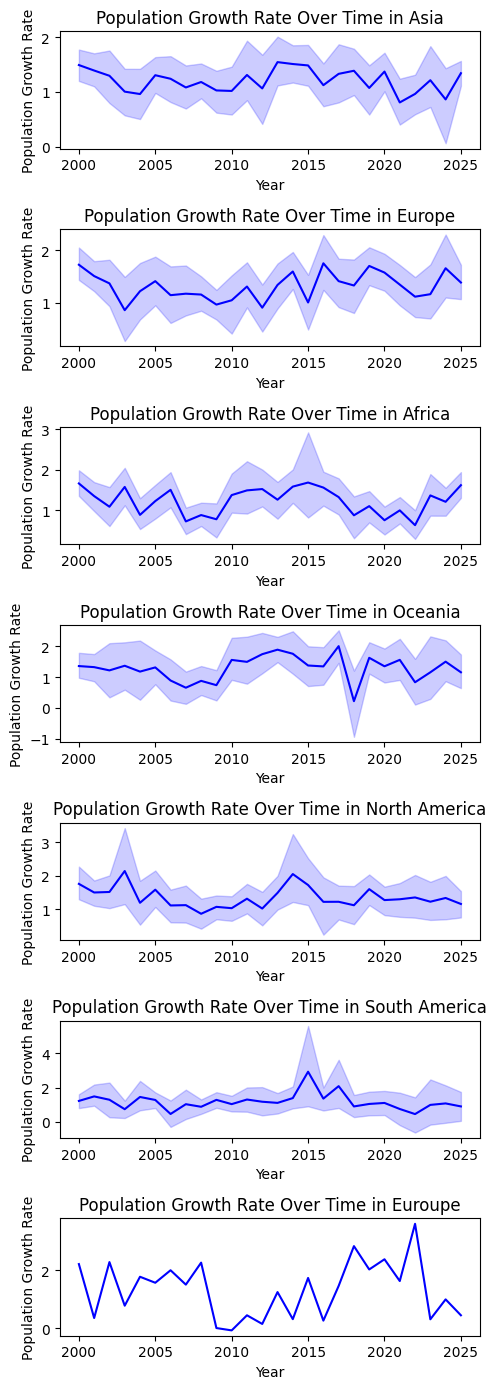

In [18]:
# Set up a grid of subplots (one for each continent)
continents = df['Continent'].unique()
num_continents = len(continents)

# Create subplots
fig, axes = plt.subplots(num_continents, 1, figsize=(5, 2 * num_continents))

# Loop through each continent and plot its population growth rate in a separate subplot
for i, continent in enumerate(continents):
    # Filter data for the continent
    continent_data = df[df['Continent'] == continent]

    # Plot Population Growth Rate for this continent
    sns.lineplot(data=continent_data, x='Year', y='Population_Growth_Rate', ax=axes[i], color='blue')

    # Add titles and labels
    axes[i].set_title(f'Population Growth Rate Over Time in {continent}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Population Growth Rate')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

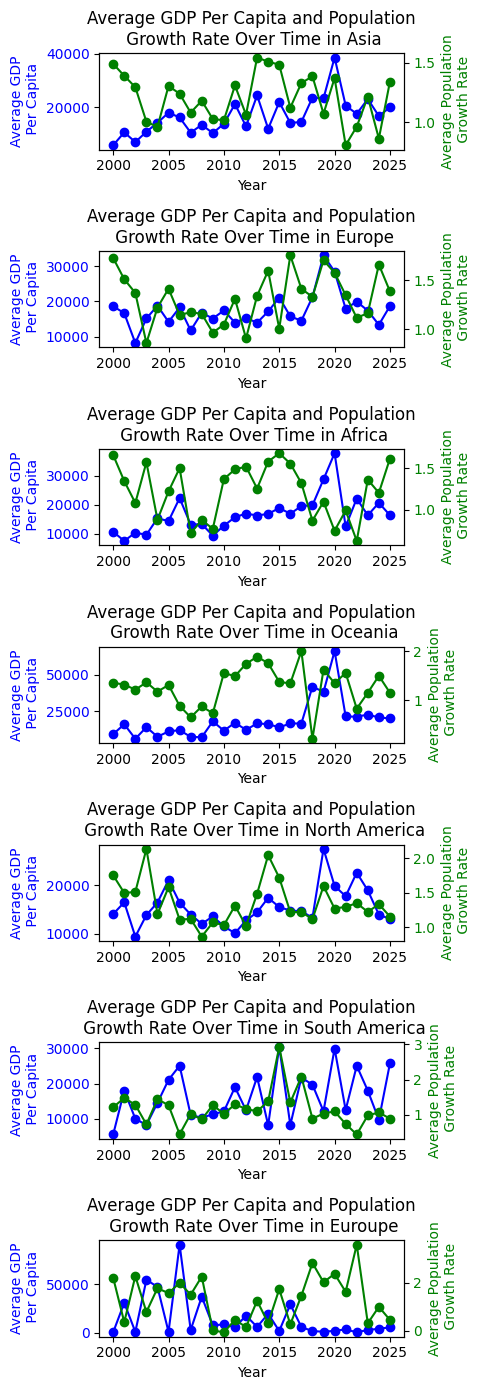

In [19]:
# Set up a grid of subplots (one for each continent)
continents = df['Continent'].unique()
num_continents = len(continents)

# Create subplots
fig, axes = plt.subplots(num_continents, 1, figsize=(5, 2
                                                     * num_continents))

# Loop through each continent and plot both GDP and Population Growth Rate on the same plot
for i, continent in enumerate(continents):
    # Group by Year and calculate the average for GDP per Capita and Population Growth Rate for each continent
    continent_data = df[df['Continent'] == continent]
    avg_data = continent_data.groupby('Year')[['GDP_Per_Capita', 'Population_Growth_Rate']].mean().reset_index()

    # Create a plot with dual y-axes
    ax1 = axes[i]
    # Plot GDP per Capita on the left y-axis
    ax1.plot(avg_data['Year'], avg_data['GDP_Per_Capita'], color='blue', label='Average GDP Per Capita', marker='o')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average GDP\n Per Capita', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Create a second y-axis for Population Growth Rate
    ax2 = ax1.twinx()
    ax2.plot(avg_data['Year'], avg_data['Population_Growth_Rate'], color='green', label='Average Population Growth Rate', marker='o')
    ax2.set_ylabel('Average Population\n Growth Rate', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Add title
    ax1.set_title(f'Average GDP Per Capita and Population\n Growth Rate Over Time in {continent}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Here we will ad two columns showing that if there was any war or disaster in a certain country, to analyse if these have affected the GDP

In [20]:
# --- Ensure consistency ---
df["Country"] = df["Country"].str.lower().str.strip()

# --- WAR events (representative major conflicts) ---
war_events = [
    ("afghanistan", 2001), ("afghanistan", 2002), ("afghanistan", 2003),
    ("iraq", 2003), ("iraq", 2004), ("iraq", 2005),
    ("syria", 2011), ("syria", 2012), ("syria", 2013),
    ("ukraine", 2014), ("ukraine", 2015), ("ukraine", 2022), ("ukraine", 2023),
    ("yemen", 2015), ("yemen", 2016),
    ("libya", 2011), ("libya", 2012),
    ("ethiopia", 2020), ("ethiopia", 2021)
]

# --- DISASTER events (major global disasters) ---
disaster_events = [
    ("japan", 2011),
    ("haiti", 2010),
    ("indonesia", 2004),
    ("pakistan", 2010),
    ("philippines", 2013),
    ("nepal", 2015),
    ("turkey", 2023),
    ("china", 2008),
    ("usa", 2005),
    ("usa", 2017),
    ("australia", 2019),
    ("india", 2013)
]

# --- Convert to DataFrames ---
war_df = pd.DataFrame(war_events, columns=["Country", "Year"])
disaster_df = pd.DataFrame(disaster_events, columns=["Country", "Year"])

# --- Create War column ---
df["War"] = df.set_index(["Country", "Year"]).index.isin(
    war_df.set_index(["Country", "Year"]).index
).astype(int)

# --- Create Disaster column ---
df["Disaster"] = df.set_index(["Country", "Year"]).index.isin(
    disaster_df.set_index(["Country", "Year"]).index
).astype(int)

df

,Year,Country,GDP_Per_Capita,Population_Growth_Rate,log_GDP,GDP_Year,Continent,War,Disaster
1,2001,afghanistan,116860.028200,1.666359,11.668732,High GDP,Asia,1,0
3,2003,afghanistan,40354.281030,-1.059785,10.605453,High GDP,Asia,1,0
4,2004,afghanistan,2446.909499,-0.417931,7.802581,Low GDP,Asia,0,0
5,2005,afghanistan,72004.743700,1.200776,11.184487,High GDP,Asia,0,0
6,2006,afghanistan,6069.439031,-1.543137,8.711021,High GDP,Asia,0,0
...,...,...,...,...,...,...,...,...,...
5065,2021,zimbabwe,824.028192,1.402030,6.714205,Low GDP,Africa,0,0
5066,2022,zimbabwe,2877.393314,-0.522606,7.964640,Low GDP,Africa,0,0
5067,2023,zimbabwe,2578.666894,2.009991,7.855028,Low GDP,Africa,0,0
5068,2024,zimbabwe,4009.320221,1.003451,8.296377,Low GDP,Africa,0,0


Now, let's check if these disasters and wars affected GDP?

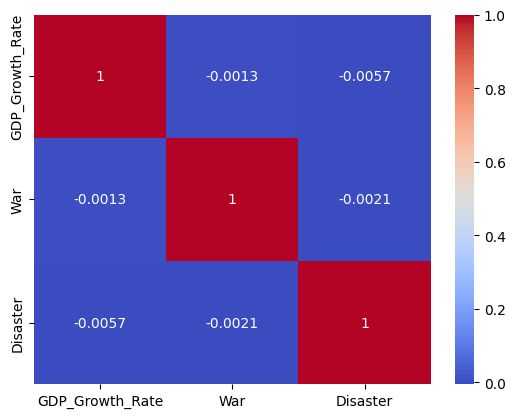

In [21]:
# create GDP growth column

df = df.sort_values(["Country", "Year"])

df["GDP_Growth_Rate"] = df.groupby("Country")["GDP_Per_Capita"].pct_change() * 100
df

corr_df = df[["GDP_Growth_Rate", "War", "Disaster"]].dropna()
corr_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
df.groupby("War")["GDP_Growth_Rate"].mean()
df.groupby("Disaster")["GDP_Growth_Rate"].mean()

,GDP_Growth_Rate
Disaster,
0,864.301365
1,467.954273


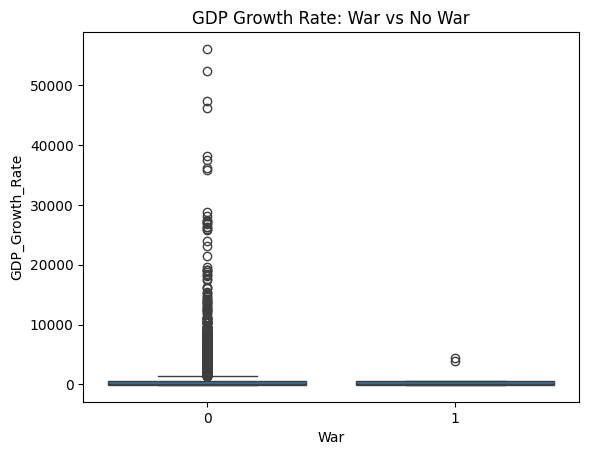

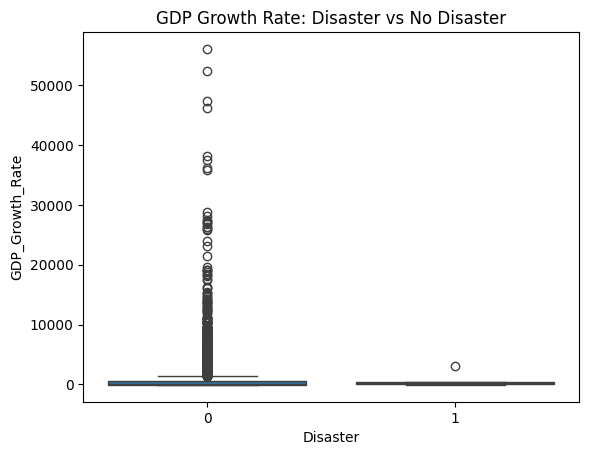

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="War", y="GDP_Growth_Rate")
plt.title("GDP Growth Rate: War vs No War")
plt.show()

sns.boxplot(data=df, x="Disaster", y="GDP_Growth_Rate")
plt.title("GDP Growth Rate: Disaster vs No Disaster")
plt.show()

Since war and disasters effect in the following years as well, we give the 3 years lad and again see.

In [23]:
df = df.sort_values(["Country", "Year"])

df["War_Lag1"] = df.groupby("Country")["War"].shift(1).fillna(0)
df["Disaster_Lag1"] = df.groupby("Country")["Disaster"].shift(1).fillna(0)

corr_df_lag = df[["GDP_Growth_Rate", "War", "War_Lag1", "Disaster", "Disaster_Lag1"]].dropna()

corr_df_lag.corr()

,GDP_Growth_Rate,War,War_Lag1,Disaster,Disaster_Lag1
GDP_Growth_Rate,1.000000,-0.001285,0.002405,-0.005665,-0.010548
War,-0.001285,1.000000,0.559315,-0.002148,-0.002148
War_Lag1,0.002405,0.559315,1.000000,-0.002236,-0.002236
Disaster,-0.005665,-0.002148,-0.002236,1.000000,-0.001860
Disaster_Lag1,-0.010548,-0.002148,-0.002236,-0.001860,1.000000


As predicted, these correlations are more. But still because of the number of rows, this correlation is not so naturaly shown

First Hypothesis Testing:

H0= There is no significant relation between GDP per capita and Population growth rate.

H1= There is a significant relation between GDP per capita and population growth rate.

In [24]:
from scipy.stats import pearsonr

# Perform Pearson correlation test
correlation, p_value = pearsonr(df['GDP_Per_Capita'], df['Population_Growth_Rate'])

# Output the results
print(f"Pearson Correlation: {correlation}")
print(f"P-value: {p_value}")

# Interpret the result
if p_value < 0.05:
    print("The correlation is statistically significant (reject H0).")
else:
    print("The correlation is not statistically significant (fail to reject H0).")

Pearson Correlation: -0.07569881415447346
P-value: 7.34149487476245e-08
The correlation is statistically significant (reject H0).


In this method, if the p-value is less than 0.05, we do reject the H0.

Second Hypothesis Testing:

H0 = There is no significant relation between log-GDP and Population growth rate.

H1 = There is a significant relation between log-GDP and Population growth rate.

In [25]:
# Perform Pearson correlation test with log_GDP
correlation_log, p_value_log = pearsonr(df['log_GDP'], df['Population_Growth_Rate'])

# Output the results
print(f"Pearson Correlation (log GDP vs Population Growth Rate): {correlation_log}")
print(f"P-value: {p_value_log}")

# Interpret the result
if p_value_log < 0.05:
    print("The correlation is statistically significant (reject H0).")
else:
    print("The correlation is not statistically significant (fail to reject H0).")

Pearson Correlation (log GDP vs Population Growth Rate): -0.27348655781223363
P-value: 3.152602640762998e-87
The correlation is statistically significant (reject H0).


Third Hypothesis Testing:

H0 = The mean population growth rate is not too much fifferent across all continents.

H1 = The mean population growth rate differs significantly across at least one continent.

In [26]:
from scipy.stats import f_oneway
import scipy.stats as stats

# Group the data by continent
asia = df[df['Continent'] == 'Asia']['Population_Growth_Rate']
africa = df[df['Continent'] == 'Africa']['Population_Growth_Rate']
europe = df[df['Continent'] == 'Europe']['Population_Growth_Rate']
north_america = df[df['Continent'] == 'North America']['Population_Growth_Rate']
south_america = df[df['Continent'] == 'South America']['Population_Growth_Rate']
oceania = df[df['Continent'] == 'Oceania']['Population_Growth_Rate']

# Perform the ANOVA test
f_stat, p_value_anova = stats.f_oneway(asia, africa, europe, north_america, south_america, oceania)

# Print out the results
print(f"ANOVA F-statistic: {f_stat}")
print(f"P-value for ANOVA: {p_value_anova}")
# Interpret the result
if p_value_anova < 0.05:
    print("The population growth rate differs significantly across continents (reject H0).")
else:
    print("The population growth rate does not differ significantly across continents (fail to reject H0).")

ANOVA F-statistic: 1.3575706039016082
P-value for ANOVA: 0.2371045050762398
The population growth rate does not differ significantly across continents (fail to reject H0).


Fourth Hypothesis Test:

H0: Mean GDP growth is the same in war and non-war country-years.

H1: Mean GDP growth is different in war and non-war country-years.

In [27]:
from scipy.stats import ttest_ind

# Make sure GDP growth is calculated correctly by country
df = df.sort_values(["Country", "Year"])
df["GDP_Growth_Rate"] = df.groupby("Country")["GDP_Per_Capita"].pct_change() * 100

# Remove missing GDP growth values
test_df = df[["Country", "Year", "GDP_Growth_Rate", "War", "Disaster"]].dropna()

# -------------------------------
# Hypothesis Test 1: War and GDP Growth
# -------------------------------

war_gdp = test_df[test_df["War"] == 1]["GDP_Growth_Rate"]
no_war_gdp = test_df[test_df["War"] == 0]["GDP_Growth_Rate"]

war_test = ttest_ind(war_gdp, no_war_gdp, equal_var=False)

print("Mean GDP Growth during War:", war_gdp.mean())
print("Mean GDP Growth with No War:", no_war_gdp.mean())
print("t-statistic:", war_test.statistic)
print("p-value:", war_test.pvalue)
# Interpretation
if p_value_anova < 0.05:
    print("GDP growth differs significantly between war and non-war observations (reject H0).")
else:
    print("GDP growth does not differ significantly between war and non-war observations (fail to reject H0).")


Mean GDP Growth during War: 785.8680441007767
Mean GDP Growth with No War: 863.7584824604827
t-statistic: -0.1697962645948693
p-value: 0.8681987971405933
GDP growth does not differ significantly between war and non-war observations (fail to reject H0).


Fifth Hypothesis Test:

H0: Mean GDP growth is the same in disaster and non-disaster country-years.

H1: Mean GDP growth is different in disaster and non-disaster country-years.

In [28]:
df

,Year,Country,GDP_Per_Capita,Population_Growth_Rate,log_GDP,GDP_Year,Continent,War,Disaster,GDP_Growth_Rate,War_Lag1,Disaster_Lag1
1,2001,afghanistan,116860.028200,1.666359,11.668732,High GDP,Asia,1,0,NaN,0.0,0.0
3,2003,afghanistan,40354.281030,-1.059785,10.605453,High GDP,Asia,1,0,-65.467849,1.0,0.0
4,2004,afghanistan,2446.909499,-0.417931,7.802581,Low GDP,Asia,0,0,-93.936431,1.0,0.0
5,2005,afghanistan,72004.743700,1.200776,11.184487,High GDP,Asia,0,0,2842.681114,0.0,0.0
6,2006,afghanistan,6069.439031,-1.543137,8.711021,High GDP,Asia,0,0,-91.570779,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
5065,2021,zimbabwe,824.028192,1.402030,6.714205,Low GDP,Africa,0,0,-92.984200,0.0,0.0
5066,2022,zimbabwe,2877.393314,-0.522606,7.964640,Low GDP,Africa,0,0,249.186271,0.0,0.0
5067,2023,zimbabwe,2578.666894,2.009991,7.855028,Low GDP,Africa,0,0,-10.381842,0.0,0.0
5068,2024,zimbabwe,4009.320221,1.003451,8.296377,Low GDP,Africa,0,0,55.480346,0.0,0.0


In [29]:
# Groups
disaster = df[df["Disaster"] == 1]["GDP_Growth_Rate"].dropna()
no_disaster = df[df["Disaster"] == 0]["GDP_Growth_Rate"].dropna()

# ANOVA
f_stat, p_value_anova = stats.f_oneway(disaster, no_disaster)

# Output
print(f"\nANOVA F-statistic: {f_stat}")
print(f"P-value for ANOVA: {p_value_anova}")

# Interpretation
if p_value_anova < 0.05:
    print("GDP growth differs significantly between disaster and non-disaster observations (reject H0).")
else:
    print("GDP growth does not differ significantly between disaster and non-disaster observations (fail to reject H0).")


ANOVA F-statistic: 0.15557342272400815
P-value for ANOVA: 0.6932824508464557
GDP growth does not differ significantly between disaster and non-disaster observations (fail to reject H0).



Linear Regression Results
MAE: 0.9670048513205769
RMSE: 1.381627294294805
R² Score: 0.09504804231323383

Random Forest Regression Results
MAE: 0.896921063217476
RMSE: 1.3146992076448598
R² Score: 0.18059894677342359

XGBoost Regression Results
MAE: 0.9447754714708352
RMSE: 1.4026759347204714
R² Score: 0.06726471242228416

Model Comparison:
               Model       MAE      RMSE        R2
0  Linear Regression  0.967005  1.381627  0.095048
1      Random Forest  0.896921  1.314699  0.180599
2            XGBoost  0.944775  1.402676  0.067265

Random Forest Feature Importance:
                    Feature  Importance
0                   log_GDP    0.556925
1           GDP_Growth_Rate    0.367885
9   Continent_North America    0.016752
6            Continent_Asia    0.012913
11  Continent_South America    0.012600
7          Continent_Europe    0.010744
12         GDP_Year_Low GDP    0.010054
10        Continent_Oceania    0.006219
4                  War_Lag1    0.002470
3                 

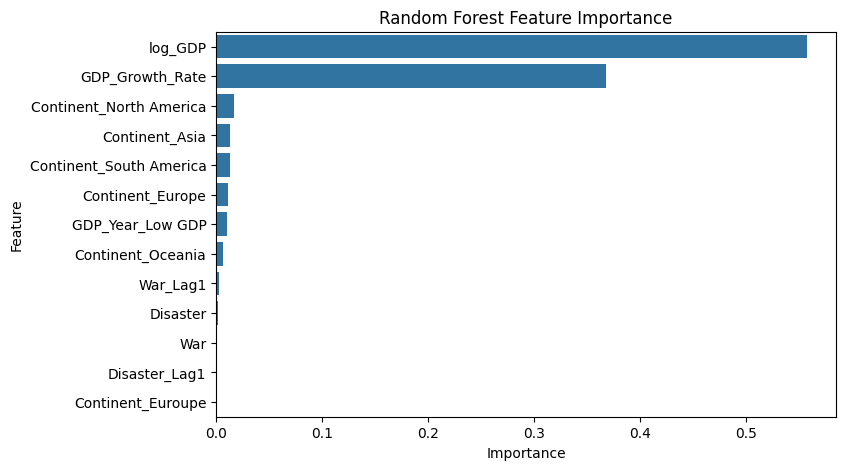


XGBoost Feature Importance:
                    Feature  Importance
0                   log_GDP    0.170349
9   Continent_North America    0.167076
12         GDP_Year_Low GDP    0.119691
1           GDP_Growth_Rate    0.107081
11  Continent_South America    0.101580
6            Continent_Asia    0.091063
10        Continent_Oceania    0.057841
4                  War_Lag1    0.056991
7          Continent_Europe    0.036274
3                  Disaster    0.033728
5             Disaster_Lag1    0.028513
2                       War    0.019322
8         Continent_Euroupe    0.010491


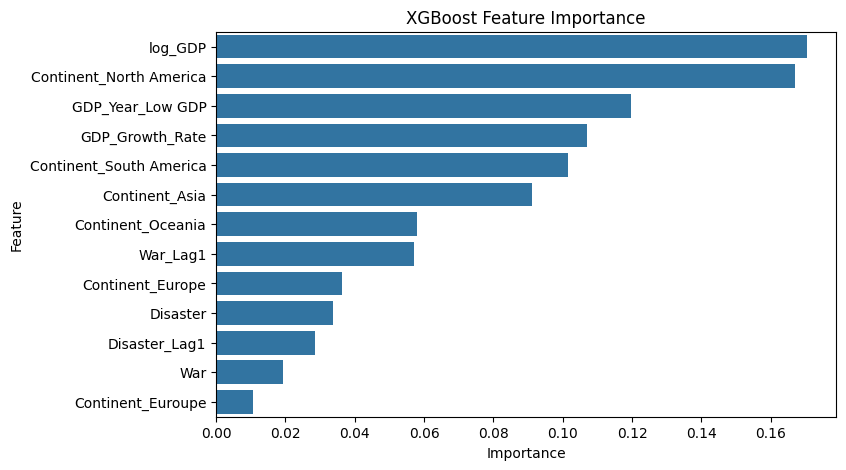


K-Means Cluster Counts:
Cluster
0    4828
2      12
1       9
Name: count, dtype: int64

Cluster Averages:
          log_GDP  GDP_Growth_Rate  Population_Growth_Rate  War  Disaster  \
Cluster                                                                     
0        8.683054       865.131907                1.251204  0.0  0.001864   
1        7.965781       126.992712                1.541960  0.0  0.000000   
2        8.805716       785.868044                0.605032  1.0  0.000000   

         War_Lag1  Disaster_Lag1  
Cluster                           
0        0.001243            0.0  
1        0.000000            1.0  
2        0.583333            0.0  


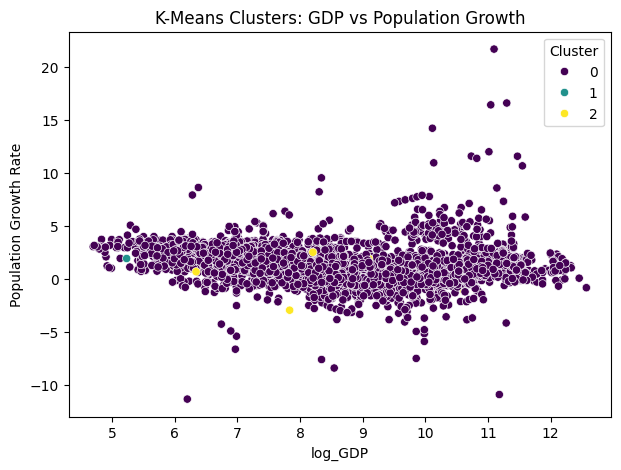

In [ ]:
# ===============================
# ML METHODS: Regression + K-Means + XGBoost
# Target: Predict Population Growth Rate
# ===============================

# If xgboost is not installed, run this once:
# !pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans

from xgboost import XGBRegressor


# -------------------------------
# 1. Prepare ML dataset
# -------------------------------

ml_df = df[[
    "Population_Growth_Rate",
    "log_GDP",
    "GDP_Growth_Rate",
    "War",
    "Disaster",
    "War_Lag1",
    "Disaster_Lag1",
    "Continent",
    "GDP_Year"
]].dropna()

# One-hot encode categorical columns
ml_df = pd.get_dummies(
    ml_df,
    columns=["Continent", "GDP_Year"],
    drop_first=True
)

# Features and target
X = ml_df.drop(columns=["Population_Growth_Rate"])
y = ml_df["Population_Growth_Rate"]


# -------------------------------
# 2. Train-test split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# -------------------------------
# 3. Helper function for evaluation
# -------------------------------

def evaluate_model(model_name, y_test, y_pred):
    print(f"\n{model_name} Results")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R² Score:", r2_score(y_test, y_pred))


# -------------------------------
# 4. Linear Regression
# -------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

evaluate_model("Linear Regression", y_test, y_pred_linear)


# -------------------------------
# 5. Random Forest Regression
# -------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

evaluate_model("Random Forest Regression", y_test, y_pred_rf)


# -------------------------------
# 6. XGBoost Regression
# -------------------------------

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

evaluate_model("XGBoost Regression", y_test, y_pred_xgb)


# -------------------------------
# 7. Compare model results visually
# -------------------------------

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    "R2": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

print("\nModel Comparison:")
print(results)


# -------------------------------
# 8. Feature importance: Random Forest
# -------------------------------

feature_importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importance:")
print(feature_importance_rf)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance_rf, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()


# -------------------------------
# 9. Feature importance: XGBoost
# -------------------------------

feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nXGBoost Feature Importance:")
print(feature_importance_xgb)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance_xgb, x="Importance", y="Feature")
plt.title("XGBoost Feature Importance")
plt.show()


# ===============================
# 10. K-MEANS CLUSTERING
# ===============================

cluster_df = df[[
    "log_GDP",
    "GDP_Growth_Rate",
    "Population_Growth_Rate",
    "War",
    "Disaster",
    "War_Lag1",
    "Disaster_Lag1"
]].dropna()

scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_df)

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["Cluster"] = kmeans.fit_predict(cluster_scaled)

print("\nK-Means Cluster Counts:")
print(cluster_df["Cluster"].value_counts())

print("\nCluster Averages:")
print(cluster_df.groupby("Cluster").mean())


# -------------------------------
# 11. Visualize clusters
# -------------------------------

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=cluster_df,
    x="log_GDP",
    y="Population_Growth_Rate",
    hue="Cluster",
    palette="viridis"
)
plt.title("K-Means Clusters: GDP vs Population Growth")
plt.xlabel("log_GDP")
plt.ylabel("Population Growth Rate")
plt.show()

Linear Regression, Random Forest Regression, and XGBoost Regression were used to predict population growth rate based on economic, regional, and event-based variables. Linear Regression served as the baseline model, while Random Forest and XGBoost were used to capture non-linear relationships. K-Means clustering was also applied to group country-year observations into similar economic-demographic profiles.

As we can see the R^2 are so low because of having all features included. We have to eliminate the unnecessary ones. We use population growth rate only here since our proposal was so.

**Linear Regression**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Logistic Regression ===
Accuracy: 0.5639097744360902

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.80      0.67       311
           1       0.39      0.32      0.35       310
           2       0.73      0.57      0.64       310

    accuracy                           0.56       931
   macro avg       0.56      0.56      0.55       931
weighted avg       0.56      0.56      0.55       931



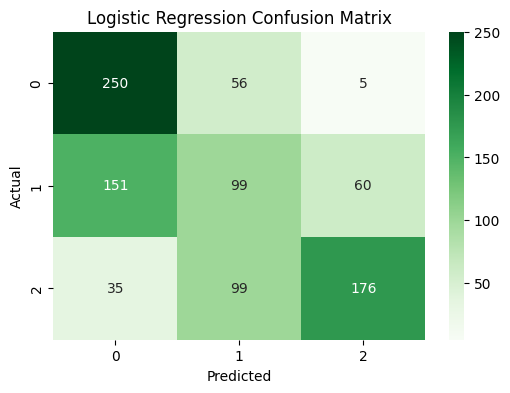

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, multi_class="multinomial")
log_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_log = log_model.predict(X_test_scaled)

# Evaluation
print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()



**Random Forest**

Accuracy: 0.6616541353383458

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.78      0.74       311
           1       0.55      0.52      0.54       310
           2       0.72      0.68      0.70       310

    accuracy                           0.66       931
   macro avg       0.66      0.66      0.66       931
weighted avg       0.66      0.66      0.66       931



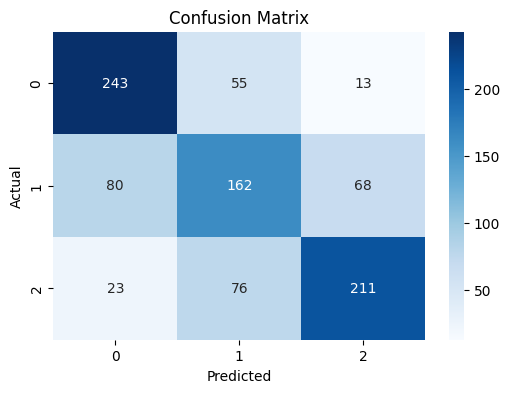

In [ ]:
# -------------------------------
# 1. Imports
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# -------------------------------
# 3. Preprocessing
# -------------------------------
df = df.sort_values(by=["Country", "Year"])

# GDP Growth
df["GDP_Growth"] = df.groupby("Country")["GDP_Per_Capita"].pct_change()

# Drop NaN
df = df.dropna()

# Classification target (3 classes)
df["Growth_Class"] = pd.qcut(df["GDP_Growth"], q=3, labels=[0,1,2])


# -------------------------------
# 4. Features & Target
# -------------------------------
features = ["GDP_Per_Capita", "Population_Growth_Rate"]
X = df[features]
y = df["Growth_Class"]


# -------------------------------
# 5. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# -------------------------------
# 6. Model (Random Forest)
# -------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)


# -------------------------------
# 7. Prediction
# -------------------------------
y_pred = rf_model.predict(X_test)


# -------------------------------
# 8. Evaluation
# -------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


# -------------------------------
# 9. Confusion Matrix (Visualization)
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**XG-Boost**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.5690721649484536

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.85      0.69       324
           1       0.39      0.28      0.33       323
           2       0.70      0.58      0.63       323

    accuracy                           0.57       970
   macro avg       0.56      0.57      0.55       970
weighted avg       0.56      0.57      0.55       970



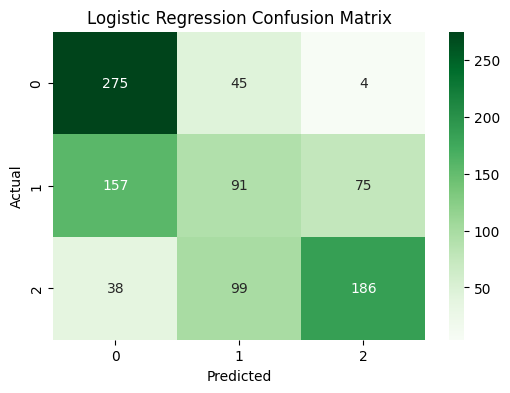

In [ ]:
# -------------------------------
# 1. Imports
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# -------------------------------
# 3. Preprocessing
# -------------------------------
df = df.sort_values(by=["Country", "Year"])

# GDP growth
df["GDP_Growth"] = df.groupby("Country")["GDP_Per_Capita"].pct_change()

# Drop NaN
df = df.dropna()

# Classification target (3 classes)
df["Growth_Class"] = pd.qcut(df["GDP_Growth"], q=3, labels=[0, 1, 2]).astype(int)


# -------------------------------
# 4. Features & Target
# -------------------------------
features = ["GDP_Per_Capita", "Population_Growth_Rate"]
X = df[features]
y = df["Growth_Class"]


# -------------------------------
# 5. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# -------------------------------
# 6. Scaling (important for Logistic Regression)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -------------------------------
# 7. Model
# -------------------------------
model = LogisticRegression(max_iter=1000, multi_class="multinomial")
model.fit(X_train_scaled, y_train)


# -------------------------------
# 8. Prediction
# -------------------------------
y_pred = model.predict(X_test_scaled)


# -------------------------------
# 9. Evaluation
# -------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# -------------------------------
# 10. Confusion Matrix (replacement for vis)
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Baseline Model Comparison


,Model,Baseline Accuracy,Baseline F1 Macro
2,Random Forest,0.660825,0.658432
3,Gradient Boosting,0.630928,0.627211
1,Decision Tree,0.618557,0.618944
4,KNN,0.620619,0.616709
5,SVM,0.589691,0.576248
0,Logistic Regression,0.569072,0.550504



Tuning Logistic Regression...

Tuning Decision Tree...

Tuning Random Forest...

Tuning Gradient Boosting...

Tuning KNN...

Tuning SVM...
Tuned Model Comparison


,Model,Best Parameters,Tuned Accuracy,Tuned F1 Macro
2,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_...",0.673196,0.668564
4,KNN,"{'model__n_neighbors': 11, 'model__weights': '...",0.668041,0.663585
3,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.630928,0.627846
1,Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 4, 'min_...",0.621649,0.618158
5,SVM,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.590722,0.583661
0,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'lbfgs'}",0.568041,0.548372


Final Baseline vs Tuned Comparison


,Model,Baseline Accuracy,Baseline F1 Macro,Tuned Accuracy,Tuned F1 Macro,Best Parameters
0,Random Forest,0.660825,0.658432,0.673196,0.668564,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."
3,KNN,0.620619,0.616709,0.668041,0.663585,"{'model__n_neighbors': 11, 'model__weights': '..."
1,Gradient Boosting,0.630928,0.627211,0.630928,0.627846,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est..."
2,Decision Tree,0.618557,0.618944,0.621649,0.618158,"{'max_depth': 10, 'min_samples_leaf': 4, 'min_..."
4,SVM,0.589691,0.576248,0.590722,0.583661,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
5,Logistic Regression,0.569072,0.550504,0.568041,0.548372,"{'model__C': 0.1, 'model__solver': 'lbfgs'}"


Best Model: Random Forest
              precision    recall  f1-score   support

           0       0.71      0.79      0.75       324
           1       0.58      0.50      0.54       323
           2       0.71      0.72      0.72       323

    accuracy                           0.67       970
   macro avg       0.67      0.67      0.67       970
weighted avg       0.67      0.67      0.67       970



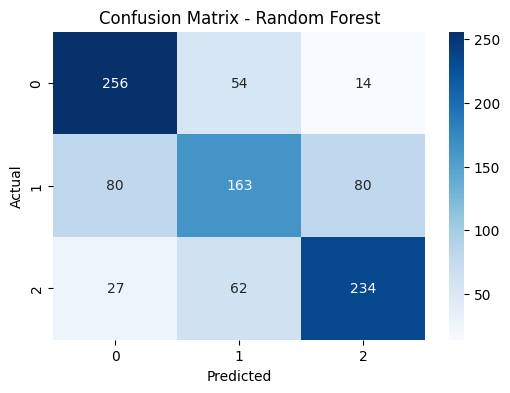

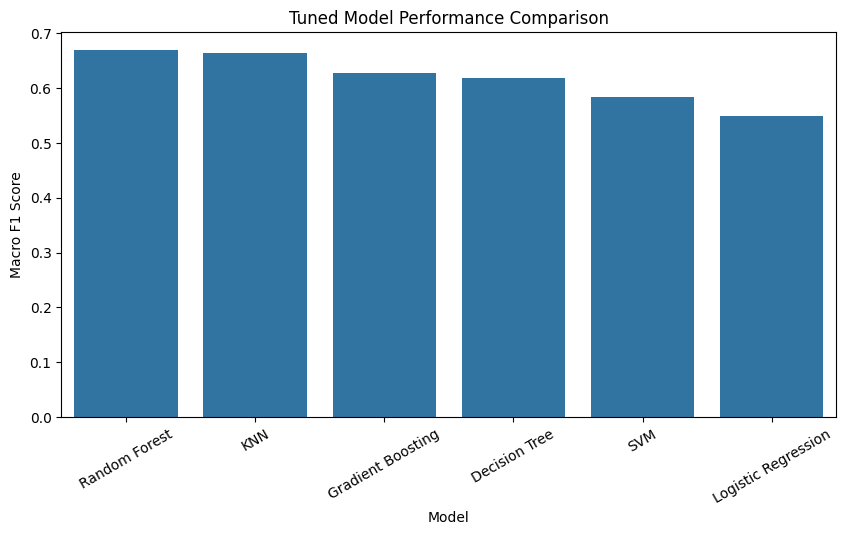

In [36]:
# ============================================================
# MODEL COMPARISON AND HYPERPARAMETER TUNING
# This section is added to address the TA's feedback.
# ============================================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 1. Keep the old project target: GDP growth class
# ------------------------------------------------------------

df = df.sort_values(by=["Country", "Year"])

df["GDP_Growth"] = df.groupby("Country")["GDP_Per_Capita"].pct_change()

df_ml = df.dropna(subset=[
    "GDP_Growth",
    "GDP_Per_Capita",
    "Population_Growth_Rate"
]).copy()

df_ml["Growth_Class"] = pd.qcut(
    df_ml["GDP_Growth"],
    q=3,
    labels=[0, 1, 2]
).astype(int)

features = ["GDP_Per_Capita", "Population_Growth_Rate"]

X = df_ml[features]
y = df_ml["Growth_Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 2. Baseline models
# ------------------------------------------------------------

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC())
    ])
}

baseline_results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    baseline_results.append({
        "Model": model_name,
        "Baseline Accuracy": accuracy_score(y_test, y_pred),
        "Baseline F1 Macro": f1_score(y_test, y_pred, average="macro")
    })

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.sort_values(by="Baseline F1 Macro", ascending=False)

print("Baseline Model Comparison")
display(baseline_df)

# ------------------------------------------------------------
# 3. Hyperparameter grids
# ------------------------------------------------------------

param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs"]
    },

    "Decision Tree": {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "max_depth": [2, 3, 5]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 11],
        "model__weights": ["uniform", "distance"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    }
}

# ------------------------------------------------------------
# 4. GridSearchCV tuning
# ------------------------------------------------------------

tuned_results = []
best_models = {}

for model_name, model in models.items():
    print(f"\nTuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        cv=5,
        scoring="f1_macro",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model

    y_pred_tuned = best_model.predict(X_test)

    tuned_results.append({
        "Model": model_name,
        "Best Parameters": grid_search.best_params_,
        "Tuned Accuracy": accuracy_score(y_test, y_pred_tuned),
        "Tuned F1 Macro": f1_score(y_test, y_pred_tuned, average="macro")
    })

tuned_df = pd.DataFrame(tuned_results)
tuned_df = tuned_df.sort_values(by="Tuned F1 Macro", ascending=False)

print("Tuned Model Comparison")
display(tuned_df)

# ------------------------------------------------------------
# 5. Final baseline vs tuned comparison
# ------------------------------------------------------------

comparison_df = baseline_df.merge(tuned_df, on="Model")

comparison_df = comparison_df[
    [
        "Model",
        "Baseline Accuracy",
        "Baseline F1 Macro",
        "Tuned Accuracy",
        "Tuned F1 Macro",
        "Best Parameters"
    ]
]

comparison_df = comparison_df.sort_values(by="Tuned F1 Macro", ascending=False)

print("Final Baseline vs Tuned Comparison")
display(comparison_df)

# ------------------------------------------------------------
# 6. Best model evaluation
# ------------------------------------------------------------

best_model_name = comparison_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_model_name}")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# ------------------------------------------------------------
# 7. Tuned model comparison plot
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Tuned F1 Macro"
)
plt.xticks(rotation=30)
plt.title("Tuned Model Performance Comparison")
plt.ylabel("Macro F1 Score")
plt.xlabel("Model")
plt.show()


This section compares several supervised machine learning models for predicting GDP growth class. Logistic Regression is used as a simple baseline because it assumes mostly linear decision boundaries. Decision Tree can capture nonlinear relationships but may overfit if it grows too deep. Random Forest usually performs better than a single Decision Tree because it combines many trees and reduces overfitting through averaging. Gradient Boosting can perform well because it builds trees sequentially and corrects previous errors, but it is more sensitive to learning rate and tree depth. KNN depends strongly on feature scaling and local similarity between observations. SVM can create stronger decision boundaries after tuning, but it is sensitive to the kernel and regularization parameter.

Hyperparameter tuning was applied using GridSearchCV. This improves the analysis because each model is evaluated not only with default settings, but also with a set of alternative parameter combinations. Accuracy and macro F1-score are both reported. Macro F1-score is especially useful because it evaluates performance across all three GDP growth classes more fairly than accuracy alone.

The tuned model comparison shows which model performed best after optimization. Differences in performance are mainly caused by each model’s ability to capture nonlinear relationships between GDP per capita, population growth rate, and GDP growth class.

**K-Means**

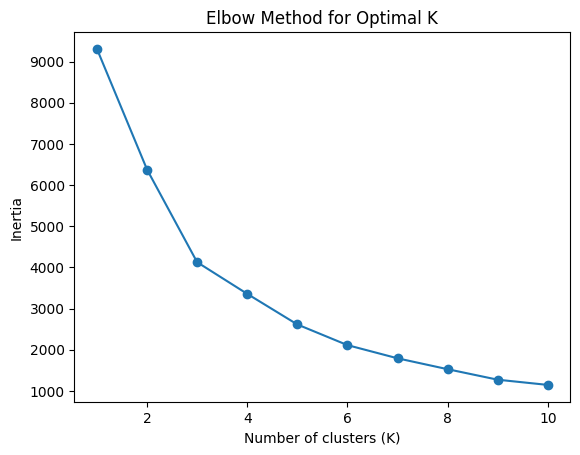

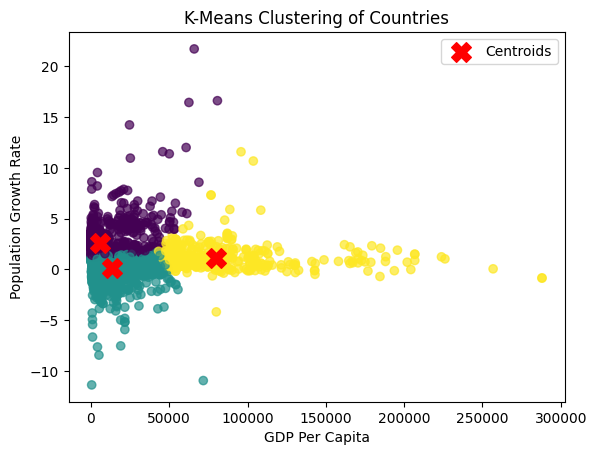

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Optional: ensure consistent ordering
df = df.dropna(subset=["GDP_Per_Capita", "Population_Growth_Rate"])
df = df.sort_values(by=["Country", "Year"])

# 1. Select features
features = ["GDP_Per_Capita", "Population_Growth_Rate"]
X = df[features]

# 2. Scale features (IMPORTANT for K-Means)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow Method (choose optimal K)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

# 4. Fit final K-Means model
# (choose K=3 or based on elbow plot)
k = 3  # adjust after checking elbow plot
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# 5. Scatter plot visualization
plt.figure()
plt.scatter(
    df["GDP_Per_Capita"],
    df["Population_Growth_Rate"],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("K-Means Clustering of Countries")
plt.xlabel("GDP Per Capita")
plt.ylabel("Population Growth Rate")

# plot cluster centers (inverse transform to original scale)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.legend()
plt.show()